# 05. 案例实战

这一章给出一组覆盖 SimPy 主要功能的案例。代码都可以单独保存为 `.py` 文件运行。案例不是为了复杂，而是为了展示不同建模模式。

## 案例 1：汽车停车和行驶

覆盖功能：进程、超时、仿真时间。

In [1]:
import simpy


def car(env):
    while True:
        print(f"{env.now}: 停车")
        yield env.timeout(5)

        print(f"{env.now}: 行驶")
        yield env.timeout(2)


env = simpy.Environment()
env.process(car(env))
env.run(until=15)

0: 停车
5: 行驶
7: 停车
12: 行驶
14: 停车


这个案例是最小循环过程。它展示了 SimPy 如何用 `yield env.timeout()` 推进仿真时间。

## 案例 2：汽车充电被驾驶员中断

覆盖功能：进程等待、子进程、中断。

In [2]:
import simpy


def charge(env):
    try:
        print(f"{env.now}: 开始充电")
        yield env.timeout(10)
        print(f"{env.now}: 充电完成")
    except simpy.Interrupt as interrupt:
        print(f"{env.now}: 充电中断，原因: {interrupt.cause}")


def car(env):
    charging = env.process(charge(env))
    yield env.timeout(3)
    charging.interrupt("驾驶员需要出发")
    print(f"{env.now}: 汽车离开")


env = simpy.Environment()
env.process(car(env))
env.run()

0: 开始充电
3: 汽车离开
3: 充电中断，原因: 驾驶员需要出发


这个模式适合任务取消、超时取消、设备故障和抢占式执行。


## 案例 3：共享充电桩

覆盖功能：`Resource`、排队、等待时间统计。

In [3]:
import random
import simpy


def car(env, name, charger, waits):
    arrive = env.now
    print(f"{env.now:.1f}: {name} 到达")

    with charger.request() as req:
        yield req
        wait = env.now - arrive
        waits.append(wait)

        charge_time = random.uniform(2, 5)
        print(f"{env.now:.1f}: {name} 开始充电，等待 {wait:.1f}")
        yield env.timeout(charge_time)
        print(f"{env.now:.1f}: {name} 充电完成")


def arrivals(env, charger, waits, count):
    for i in range(count):
        env.process(car(env, f"car-{i}", charger, waits))
        yield env.timeout(random.expovariate(0.7))


random.seed(1)
env = simpy.Environment()
charger = simpy.Resource(env, capacity=2)
waits = []

env.process(arrivals(env, charger, waits, count=8))
env.run()

print("平均等待时间:", sum(waits) / len(waits))

0.0: car-0 到达
0.0: car-0 开始充电，等待 0.0
0.2: car-1 到达
0.2: car-1 开始充电，等待 0.0
2.3: car-2 到达
3.0: car-1 充电完成
3.0: car-2 开始充电，等待 0.7
3.2: car-3 到达
4.5: car-0 充电完成
4.5: car-3 开始充电，等待 1.3
4.8: car-4 到达
4.9: car-5 到达
4.9: car-6 到达
6.3: car-2 充电完成
6.3: car-4 开始充电，等待 1.6
7.5: car-7 到达
8.9: car-3 充电完成
8.9: car-5 开始充电，等待 4.0
9.6: car-4 充电完成
9.6: car-6 开始充电，等待 4.7
10.9: car-5 充电完成
10.9: car-7 开始充电，等待 3.4
13.0: car-6 充电完成
15.1: car-7 充电完成
平均等待时间: 1.9591662080622563


这个案例的关键是把“车辆”建模成进程，把“充电桩”建模成资源。


## 案例 4：银行排队，顾客等不及离开

覆盖功能：`Resource`、条件事件、超时放弃。

In [4]:
import random
import simpy


def customer(env, name, counter, patience, stats):
    arrive = env.now
    print(f"{env.now:.1f}: {name} 到达")

    with counter.request() as req:
        result = yield req | env.timeout(patience)

        if req not in result:
            print(f"{env.now:.1f}: {name} 等不及离开")
            stats["reneged"] += 1
            return

        wait = env.now - arrive
        service_time = random.uniform(3, 6)
        print(f"{env.now:.1f}: {name} 开始服务，等待 {wait:.1f}")
        yield env.timeout(service_time)
        print(f"{env.now:.1f}: {name} 服务完成")
        stats["served"] += 1


def source(env, counter, stats):
    for i in range(10):
        patience = random.uniform(2, 8)
        env.process(customer(env, f"C{i}", counter, patience, stats))
        yield env.timeout(random.expovariate(0.8))


random.seed(2)
env = simpy.Environment()
counter = simpy.Resource(env, capacity=1)
stats = {"served": 0, "reneged": 0}

env.process(source(env, counter, stats))
env.run()

print(stats)

0.0: C0 到达
0.0: C0 开始服务，等待 0.0
3.2: C0 服务完成
3.7: C1 到达
3.7: C1 开始服务，等待 0.0
5.9: C2 到达
6.4: C3 到达
7.6: C4 到达
7.8: C5 到达
8.4: C6 到达
8.9: C1 服务完成
8.9: C2 开始服务，等待 3.0
12.0: C3 等不及离开
12.4: C5 等不及离开
13.1: C4 等不及离开
14.7: C2 服务完成
14.7: C6 开始服务，等待 6.3
15.0: C7 到达
15.4: C8 到达
15.4: C9 到达
17.6: C8 等不及离开
19.4: C6 服务完成
19.4: C7 开始服务，等待 4.4
20.2: C9 等不及离开
23.5: C7 服务完成
{'served': 5, 'reneged': 5}


这个案例展示了排队系统中常见的“服务请求”和“耐心耗尽”竞争。


## 案例 5：加油站库存补给

覆盖功能：`Resource`、`Container`、后台补给进程。

In [5]:
import random
import simpy


def car(env, name, pump, station_tank):
    fuel_needed = random.randint(20, 40)
    print(f"{env.now:.1f}: {name} 需要加油 {fuel_needed}")

    with pump.request() as req:
        yield req
        yield station_tank.get(fuel_needed)
        refuel_time = fuel_needed / 10
        yield env.timeout(refuel_time)
        print(f"{env.now:.1f}: {name} 加油完成，油站剩余 {station_tank.level}")


def car_generator(env, pump, station_tank):
    for i in range(12):
        env.process(car(env, f"car-{i}", pump, station_tank))
        yield env.timeout(random.expovariate(0.5))


def tank_truck(env, station_tank):
    while True:
        if station_tank.level < 50:
            print(f"{env.now:.1f}: 油量低，油罐车补给")
            yield env.timeout(5)
            yield station_tank.put(100)
            print(f"{env.now:.1f}: 补给完成，当前油量 {station_tank.level}")
        yield env.timeout(1)


random.seed(3)
env = simpy.Environment()
pump = simpy.Resource(env, capacity=2)
station_tank = simpy.Container(env, capacity=200, init=100)

env.process(car_generator(env, pump, station_tank))
env.process(tank_truck(env, station_tank))
env.run(until=50)

0.0: car-0 需要加油 37
0.5: car-1 需要加油 39
0.8: car-2 需要加油 38
1.0: 油量低，油罐车补给
2.1: car-3 需要加油 20
2.2: car-4 需要加油 35
3.7: car-0 加油完成，油站剩余 24
4.4: car-1 加油完成，油站剩余 24
6.0: 补给完成，当前油量 66
7.0: car-5 需要加油 27
7.6: car-6 需要加油 35
8.0: car-3 加油完成，油站剩余 66
8.1: car-7 需要加油 37
9.0: 油量低，油罐车补给
9.6: car-8 需要加油 40
9.8: car-2 加油完成，油站剩余 31
10.9: car-9 需要加油 27
11.5: car-4 加油完成，油站剩余 4
12.5: car-5 加油完成，油站剩余 4
14.0: 补给完成，当前油量 32
14.9: car-10 需要加油 36
15.0: 油量低，油罐车补给
16.9: car-11 需要加油 20
17.5: car-6 加油完成，油站剩余 32
17.7: car-7 加油完成，油站剩余 32
20.0: 补给完成，当前油量 65
22.7: car-9 加油完成，油站剩余 65
23.0: 油量低，油罐车补给
24.0: car-8 加油完成，油站剩余 29
26.0: car-11 加油完成，油站剩余 9
26.3: car-10 加油完成，油站剩余 9
28.0: 补给完成，当前油量 109


这里有两类约束：

- 加油枪数量有限，用 `Resource`。
- 油量库存有限，用 `Container`。

## 案例 6：机器车间故障和维修

覆盖功能：中断、资源、剩余时间、故障进程。

In [6]:
import random
import simpy


def machine(env, name, repairman, stats, state):
    while True:
        work_remaining = random.uniform(8, 12)

        while work_remaining > 0:
            try:
                state["phase"] = "working"
                start = env.now
                print(f"{env.now:.1f}: {name} 开始加工，剩余 {work_remaining:.1f}")
                yield env.timeout(work_remaining)
                stats["parts"] += 1
                print(f"{env.now:.1f}: {name} 完成一个零件")
                work_remaining = 0
            except simpy.Interrupt:
                used = env.now - start
                work_remaining -= used
                state["phase"] = "repairing"
                print(f"{env.now:.1f}: {name} 故障，剩余 {work_remaining:.1f}")

                with repairman.request() as req:
                    yield req
                    yield env.timeout(3)
                    print(f"{env.now:.1f}: {name} 维修完成")
        state["phase"] = "idle"


def breakdown_generator(env, machines):
    while True:
        yield env.timeout(random.expovariate(0.2))
        working = [
            (proc, state)
            for proc, state in machines
            if proc.is_alive and state["phase"] == "working"
        ]
        if not working:
            continue
        machine_proc, _ = random.choice(working)
        if machine_proc.is_alive:
            machine_proc.interrupt()


random.seed(4)
env = simpy.Environment()
repairman = simpy.Resource(env, capacity=1)
stats = {"parts": 0}

machines = []
for i in range(3):
    state = {"phase": "idle"}
    proc = env.process(machine(env, f"M{i}", repairman, stats, state))
    machines.append((proc, state))

env.process(breakdown_generator(env, machines))
env.run(until=50)

print("完成零件数:", stats["parts"])

0.0: M0 开始加工，剩余 8.9
0.0: M1 开始加工，剩余 8.4
0.0: M2 开始加工，剩余 9.6
0.8: M0 故障，剩余 8.1
0.9: M2 故障，剩余 8.6
3.8: M0 维修完成
3.8: M0 开始加工，剩余 8.1
6.8: M2 维修完成
6.8: M2 开始加工，剩余 8.6
8.4: M1 完成一个零件
8.4: M1 开始加工，剩余 11.1
9.0: M0 故障，剩余 2.9
12.0: M0 维修完成
12.0: M0 开始加工，剩余 2.9
12.7: M1 故障，剩余 6.8
14.3: M0 故障，剩余 0.7
15.5: M2 完成一个零件
15.5: M2 开始加工，剩余 9.0
15.7: M1 维修完成
15.7: M1 开始加工，剩余 6.8
18.7: M0 维修完成
18.7: M0 开始加工，剩余 0.7
19.3: M0 完成一个零件
19.3: M0 开始加工，剩余 11.8
22.5: M1 完成一个零件
22.5: M1 开始加工，剩余 8.1
23.1: M2 故障，剩余 1.5
26.1: M2 维修完成
26.1: M2 开始加工，剩余 1.5
27.5: M2 完成一个零件
27.5: M2 开始加工，剩余 11.2
30.6: M1 完成一个零件
30.6: M1 开始加工，剩余 8.8
31.1: M0 完成一个零件
31.1: M0 开始加工，剩余 9.2
31.3: M2 故障，剩余 7.5
34.3: M2 维修完成
34.3: M2 开始加工，剩余 7.5
39.3: M1 完成一个零件
39.3: M1 开始加工，剩余 11.8
40.3: M0 完成一个零件
40.3: M0 开始加工，剩余 11.4
41.4: M1 故障，剩余 9.8
41.7: M2 完成一个零件
41.7: M2 开始加工，剩余 10.4
41.8: M2 故障，剩余 10.3
44.4: M1 维修完成
44.4: M1 开始加工，剩余 9.8
45.4: M0 故障，剩余 6.4
46.8: M1 故障，剩余 7.4
47.4: M2 维修完成
47.4: M2 开始加工，剩余 10.3
完成零件数: 10


这个案例重点展示“外部故障进程”如何中断正在工作的机器进程。


## 案例 7：生产者消费者队列

覆盖功能：`Store`、对象队列、生产消费速率差异。

In [7]:
import random
import simpy


def producer(env, store):
    for i in range(10):
        item = {"id": i, "created": env.now}
        yield store.put(item)
        print(f"{env.now:.1f}: 生产 {item['id']}")
        yield env.timeout(random.uniform(0.5, 1.5))


def consumer(env, name, store, stats):
    while True:
        item = yield store.get()
        wait = env.now - item["created"]
        yield env.timeout(random.uniform(1, 3))
        stats.append(wait)
        print(f"{env.now:.1f}: {name} 处理 {item['id']}，队列等待 {wait:.1f}")


random.seed(5)
env = simpy.Environment()
store = simpy.Store(env, capacity=5)
stats = []

env.process(producer(env, store))
env.process(consumer(env, "worker-1", store, stats))
env.process(consumer(env, "worker-2", store, stats))
env.run(until=30)

print("平均队列等待:", sum(stats) / len(stats))

0.0: 生产 0
1.1: 生产 1
2.4: 生产 2
2.5: worker-1 处理 0，队列等待 0.0
3.7: 生产 3
4.0: worker-2 处理 1，队列等待 0.0
4.2: 生产 4
5.3: worker-1 处理 2，队列等待 0.1
5.6: 生产 5
5.9: worker-2 处理 3，队列等待 0.3
7.0: 生产 6
7.2: worker-2 处理 5，队列等待 0.3
7.6: worker-1 处理 4，队列等待 1.1
8.0: 生产 7
8.7: worker-2 处理 6，队列等待 0.1
9.0: 生产 8
9.6: 生产 9
10.1: worker-1 处理 7，队列等待 0.0
10.5: worker-2 处理 8，队列等待 0.0
13.0: worker-1 处理 9，队列等待 0.6
平均队列等待: 0.25904143997204254


适合建模消息队列、任务队列、流水线缓冲区。


## 案例 8：按类型匹配任务和实例

覆盖功能：`FilterStore`。

In [8]:
import simpy


def scheduler(env, instances, tasks):
    while True:
        task = yield tasks.get()
        instance = yield instances.get(lambda inst: inst["type"] == task["type"])

        print(f"{env.now}: 任务 {task['id']} 分配给实例 {instance['id']}")
        yield env.timeout(task["duration"])

        yield instances.put(instance)
        print(f"{env.now}: 任务 {task['id']} 完成")


def add_instances(env, instances):
    yield instances.put({"id": "cpu-1", "type": "cpu"})
    yield instances.put({"id": "gpu-1", "type": "gpu"})


def submitter(env, tasks):
    data = [
        {"id": "A", "type": "cpu", "duration": 3},
        {"id": "B", "type": "gpu", "duration": 5},
        {"id": "C", "type": "cpu", "duration": 2},
    ]
    for task in data:
        yield tasks.put(task)
        yield env.timeout(1)


env = simpy.Environment()
instances = simpy.FilterStore(env)
tasks = simpy.Store(env)

env.process(add_instances(env, instances))
env.process(submitter(env, tasks))
env.process(scheduler(env, instances, tasks))
env.run()

0: 任务 A 分配给实例 cpu-1
3: 任务 A 完成
3: 任务 B 分配给实例 gpu-1
8: 任务 B 完成
8: 任务 C 分配给实例 cpu-1
10: 任务 C 完成


这个案例适合函数计算、异构集群、订单匹配等需要按属性选对象的场景。


## 案例 9：优先级任务调度

覆盖功能：`PriorityStore`。

In [9]:
import simpy
from simpy.resources.store import PriorityItem


def demo(env, queue):
    tasks = [
        (5, {"name": "low", "duration": 2}),
        (1, {"name": "high", "duration": 1}),
        (3, {"name": "mid", "duration": 1}),
    ]

    for priority, task in tasks:
        yield queue.put(PriorityItem(priority, task))

    while queue.items:
        priority_item = yield queue.get()
        task = priority_item.item
        print(f"{env.now}: 开始 {task['name']} priority={priority_item.priority}")
        yield env.timeout(task["duration"])
        print(f"{env.now}: 完成 {task['name']}")


env = simpy.Environment()
queue = simpy.PriorityStore(env)
env.process(demo(env, queue))
env.run()

0: 开始 high priority=1
1: 完成 high
1: 开始 mid priority=3
2: 完成 mid
2: 开始 low priority=5
4: 完成 low


`PriorityStore` 适合“任务进入队列后，按优先级取出”的场景。


## 案例 10：资源监控和绘图数据

覆盖功能：监控、队列长度、利用率时间序列。

In [10]:
import random
import simpy


def job(env, name, server):
    with server.request() as req:
        yield req
        yield env.timeout(random.uniform(1, 4))


def arrivals(env, server):
    for i in range(30):
        env.process(job(env, f"job-{i}", server))
        yield env.timeout(random.expovariate(1.2))


def monitor(env, server, samples, interval=0.5):
    while True:
        samples.append({
            "time": env.now,
            "busy": server.count,
            "queue": len(server.queue),
        })
        yield env.timeout(interval)


random.seed(6)
env = simpy.Environment()
server = simpy.Resource(env, capacity=3)
samples = []

env.process(arrivals(env, server))
env.process(monitor(env, server, samples))
env.run(until=30)

for row in samples[:]:
    print(row)

{'time': 0, 'busy': 0, 'queue': 0}
{'time': 0.5, 'busy': 1, 'queue': 0}
{'time': 1.0, 'busy': 1, 'queue': 0}
{'time': 1.5, 'busy': 2, 'queue': 0}
{'time': 2.0, 'busy': 3, 'queue': 1}
{'time': 2.5, 'busy': 3, 'queue': 2}
{'time': 3.0, 'busy': 3, 'queue': 2}
{'time': 3.5, 'busy': 3, 'queue': 0}
{'time': 4.0, 'busy': 3, 'queue': 2}
{'time': 4.5, 'busy': 3, 'queue': 2}
{'time': 5.0, 'busy': 3, 'queue': 1}
{'time': 5.5, 'busy': 3, 'queue': 1}
{'time': 6.0, 'busy': 3, 'queue': 2}
{'time': 6.5, 'busy': 3, 'queue': 2}
{'time': 7.0, 'busy': 3, 'queue': 3}
{'time': 7.5, 'busy': 3, 'queue': 3}
{'time': 8.0, 'busy': 3, 'queue': 2}
{'time': 8.5, 'busy': 3, 'queue': 2}
{'time': 9.0, 'busy': 3, 'queue': 2}
{'time': 9.5, 'busy': 3, 'queue': 2}
{'time': 10.0, 'busy': 3, 'queue': 1}
{'time': 10.5, 'busy': 3, 'queue': 1}
{'time': 11.0, 'busy': 3, 'queue': 1}
{'time': 11.5, 'busy': 2, 'queue': 0}
{'time': 12.0, 'busy': 3, 'queue': 0}
{'time': 12.5, 'busy': 3, 'queue': 1}
{'time': 13.0, 'busy': 3, 'queue':

如果需要绘图，可以把 `samples` 转成 Pandas DataFrame：


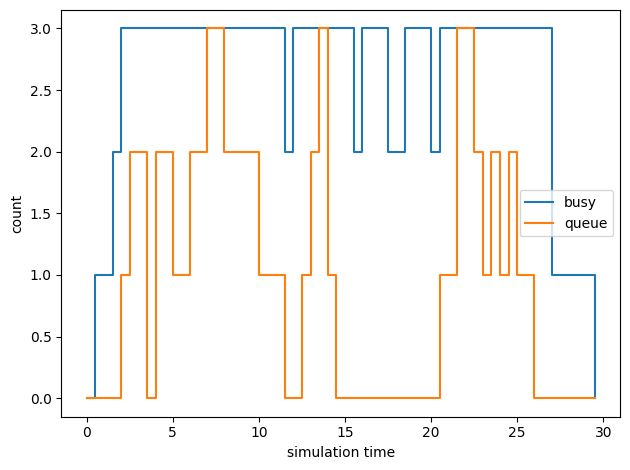

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(samples)
ax = df.plot(x="time", y=["busy", "queue"], drawstyle="steps-post")
ax.set_xlabel("simulation time")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

绘图建议：

- 队列长度、资源占用这类阶梯变化数据使用 `steps-post`。
- 多次随机实验应画均值和置信区间，不要只画单次曲线。
- 明确横轴是仿真时间，不是真实时间。
- 如果资源状态只在事件发生时变化，事件打点比固定间隔采样更精确。

## 案例 11：实时仿真演示

覆盖功能：`RealtimeEnvironment`。

In [12]:
import simpy.rt


def ticker(env):
    while True:
        print(f"仿真时间 {env.now}")
        yield env.timeout(1)


env = simpy.rt.RealtimeEnvironment(factor=1.0, strict=False)
env.process(ticker(env))
env.run(until=5)

仿真时间 0
仿真时间 1
仿真时间 2
仿真时间 3
仿真时间 4


这段代码大约每 1 秒真实时间打印一次。实时仿真适合演示和外部系统联动，不适合高性能批量实验。

## 案例选择指南

| 需求 | 参考案例 |
| --- | --- |
| 学会最小进程 | 案例 1 |
| 任务取消或外部打断 | 案例 2、6 |
| 有限服务器排队 | 案例 3、4 |
| 顾客超时离开 | 案例 4 |
| 库存和服务能力同时约束 | 案例 5 |
| 故障维修系统 | 案例 6 |
| 任务队列 | 案例 7 |
| 按属性匹配对象 | 案例 8 |
| 优先级队列 | 案例 9 |
| 统计和绘图 | 案例 10 |
| 真实时间演示 | 案例 11 |

## 从案例扩展到工程模型

把案例迁移到真实工程时，通常需要补充：

- 输入参数配置：到达率、服务时间分布、资源数量。
- 随机种子管理：保证实验可复现。
- 多次重复实验：估计均值和波动。
- 指标输出：CSV、JSON、数据库或绘图。
- 预热期处理：长稳态仿真通常要丢弃前期样本。
- 错误检查：容量不能为负、事件不能重复触发、资源必须释放。
- 模型校验：和真实系统日志或手工计算结果对比。
